In [1]:
import os
os.environ["PYHTONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import scanpy as sc
import os
import anndata as ad
import ktplotspy as kpy
import matplotlib.pyplot as plt

from cellphonedb.utils import db_utils
from cellphonedb.src.core.methods import cpdb_degs_analysis_method

%matplotlib inline
plt.rcParams["pdf.fonttype"] = "truetype"

In [4]:
import anndata2ri

anndata2ri.activate()
%load_ext rpy2.ipython

In [5]:
%%R
suppressPackageStartupMessages({
    library(Seurat)
    library(zellkonverter)
    library(SingleCellExperiment)
})

# set the working directory
project_dir <- "~/BreastCancerG0arrest/"
working_dir <- paste0(project_dir, "00_revisions/")
figure_dir <- paste0(working_dir, "figures/")
data_dir <- paste0(working_dir, "data/")
setwd(working_dir)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In addition: There were 11 warnings (use warnings() to see them)


In [7]:
%%R

# load the Seurat object
path <- "data/adata_full_harmony_integration_scenic.h5ad"
sce <- zellkonverter::readH5AD(path, reader = "R")
seurat_obj_full <- as.Seurat(sce, counts = "counts", data = NULL)

In addition: Warning messages:
1: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
2: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_harmony_ to Xpcaharmony_ 
3: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_umap_ to Xumap_ 


In [9]:
%%R
# Shorten cell type names:
Idents(seurat_obj_full) <- seurat_obj_full$celltype
seurat_obj_full <- RenameIdents(seurat_obj_full, c("PIP+ mammary luminal cell" = "PIP_luminal",
                                         "Endothelial" = "EC",
                                         "Cycling lactocyte" = "Cyc_Lac",
                                         "Macrophage" = "Macrophage",
                                         "Secretoglobin mammary luminal cell" = "Sec_luminal",
                                         "Mammary basal cell" = "Basal",
                                         "SAA2+ mammary luminal progenitor" = "SAA2_luminal",
                                         "Fibroblast" = "Fibroblast",
                                         "Cancer-associated fibroblast" = "CAF",
                                         "Tumour-associated macrophage" = "TAM",
                                         "Regulatory T cell" = "T_reg",
                                         "CD4+ T cell" = "CD4_T",
                                         "cDC" = "cDC",
                                         "NK/CD8+ T cell" = "CD8_T",
                                         "pDC" = "pDC",
                                         "SCGB3A1+ mammary luminal progenitor" = "SCGB3A1_Pro",
                                         "Cycling mammary luminal progenitor" = "Cyc_Pro",
                                         "Plasma cell" = "Plasma_cell",
                                         "B cell" = "B_cell",
                                         "Mast cell" = "Mast"))

# rename cell types
seurat_obj_full$celltype <- Idents(seurat_obj_full)
seurat_obj_full$celltype <- as.character(seurat_obj_full$celltype)
seurat_obj_full$celltype[seurat_obj_full$cycling_state_oren == "G0-arrested"] <- "G0_arrested"
seurat_obj_full$celltype[seurat_obj_full$cycling_state_oren == "Fast-cycling"] <- "Fast_cycling"
seurat_obj_full$celltype[seurat_obj_full$cycling_state_oren == "Slow-cycling"] <- "Slow_cycling"
Idents(seurat_obj_full) <- seurat_obj_full$celltype

# subset the object to only include cancer patients
seurat_obj <- subset(seurat_obj_full, subset = (disease %in% "cancer") & !(seurat_obj_full$patient %in% c("Patient.12", "Patient.13", "Patient.14", "Patient.15")))
# subset the object to only include invasive breast cancer
seurat_obj <- subset(seurat_obj, subset = type %in% c("ER", "PR", "HER", "TNBC"))
# Normalize the data
seurat_obj <- NormalizeData(seurat_obj)
table(Idents(seurat_obj))


Slow_cycling  G0_arrested           EC Fast_cycling          TAM   Fibroblast 
       52207         5628         1337        21514         4411         2763 
       T_reg        CD4_T     Pericyte   Macrophage          cDC          CAF 
        1921         1254          750         2696         3475         3600 
       CD8_T          pDC  Plasma_cell       B_cell         Mast 
        1914          606         2120         1311           97 


Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
In addition: Warning messages:
1: The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was

In [10]:
%%R
# save the metadata
metadata <- seurat_obj@meta.data
metadata$barcode_sample <- rownames(metadata)
metadata <- metadata[, c("barcode_sample", "celltype")]
colnames(metadata) <- c("barcode_sample", "cell_type")
write.table(metadata, file = "data/cellphonedb_metadata.tsv", sep = "\t", quote = F, row.names = F)

# prepare the data for CellPhoneDB
seurat_obj$cell_type <- Idents(seurat_obj)

In [11]:
%%R
# find DEGs for each cell type (for only method 3 of cellphonedb)
degs <- FindAllMarkers(seurat_obj, only.pos = TRUE, min.pct = 0.1)
degs_reordered <- degs[, c(6, 7, 5, 1, 2, 3, 4)]
colnames(degs_reordered) <- c("cell_type", "gene", "p_val_adj", "p_val", "avg_log2FC", "pct.1", "pct.2")
write.table(degs_reordered, file = "data/cellphonedb_degs.tsv", row.names = F, sep = "\t", quote = F)

Calculating cluster Slow_cycling
Calculating cluster G0_arrested
Calculating cluster EC
Calculating cluster Fast_cycling
Calculating cluster TAM
Calculating cluster Fibroblast
Calculating cluster T_reg
Calculating cluster CD4_T
Calculating cluster Pericyte
Calculating cluster Macrophage
Calculating cluster cDC
Calculating cluster CAF
Calculating cluster CD8_T
Calculating cluster pDC
Calculating cluster Plasma_cell
Calculating cluster B_cell
Calculating cluster Mast


In [12]:
%%R
# save the anndata object
sce <- as.SingleCellExperiment(seurat_obj)
writeH5AD(sce, file = "data/cellphonedb_adata.h5ad")

ℹ Using the 'counts' assay as the X matrix


In [13]:
adata = sc.read_h5ad("data/cellphonedb_adata.h5ad")

In [14]:
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [15]:
adata.write_h5ad("data/cellphonedb_adata.h5ad")

In [16]:
# -- Version of the databse
cpdb_version = "v5.0.0"

project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = os.path.join(project_dir, "00_revisions/")
figure_dir = os.path.join(working_dir, "figures/")
data_dir = os.path.join(working_dir, "data/")

cpdb_target_dir = os.path.join(data_dir, "cellphonedb/")

In [17]:
db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/
Downloaded complex_input.csv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/
Downloaded gene_input.csv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/
Downloaded interaction_input.csv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/
Downloaded protein_input.csv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/
Downloaded uniprot_synonyms.tsv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/sources
Downloaded transcription_factor_input.csv into /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb/sources


In [18]:
pd.set_option("display.max_columns", 100)

out_path = data_dir + "cellphonedb_results/"
if not os.path.exists(out_path):
    os.makedirs(out_path)
cpdb_file_path = "data/cellphonedb/cellphonedb.zip"
meta_file_path = "data/cellphonedb_metadata.tsv"
counts_file_path = "data/cellphonedb_adata.h5ad"
degs_file_path = "data/cellphonedb_degs.tsv"

In [19]:
results = cpdb_degs_analysis_method.call(
    cpdb_file_path=cpdb_file_path,
    meta_file_path=meta_file_path,
    counts_file_path=counts_file_path,
    degs_file_path=degs_file_path,
    counts_data="hgnc_symbol",
    threshold=0.1,
    threads=32,
    score_interactions=True,
    output_suffix="",
    output_path=out_path,
)

[ ][CORE][09/12/25-11:02:13][INFO] [Cluster DEGs Analysis] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
data/cellphonedb_adata.h5ad
data/cellphonedb_metadata.tsv
data/cellphonedb_degs.tsv
[ ][CORE][09/12/25-11:02:48][INFO] Running Real Analysis
[ ][CORE][09/12/25-11:02:48][INFO] Running DEGs-based Analysis
[ ][CORE][09/12/25-11:02:49][INFO] Building results
[ ][CORE][09/12/25-11:02:49][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 17/17 [00:01<00:00,  9.56it/s]

[ ][CORE][09/12/25-11:02:51][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 17/17 [00:00<00:00, 40.02it/s]


[ ][CORE][09/12/25-11:02:52][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 289/289 [00:11<00:00, 26.10it/s]


Saved deconvoluted to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_deconvoluted_.txt
Saved deconvoluted_percents to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_deconvoluted_percents_.txt
Saved means to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_means_.txt
Saved relevant_interactions to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_relevant_interactions_.txt
Saved significant_means to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_significant_means_.txt
Saved interaction_scores to /home/cenk/BreastCancerG0arrest/00_revisions/data/cellphonedb_results/degs_analysis_interaction_scores_.txt


In [20]:
adata = ad.read_h5ad(counts_file_path)
means = pd.read_csv(out_path + "degs_analysis_means_.txt", sep="\t")
pvals = pd.read_csv(out_path + "degs_analysis_relevant_interactions_.txt", sep="\t")
decon = pd.read_csv(out_path + "degs_analysis_deconvoluted_.txt", sep="\t")
scores = pd.read_csv(out_path + "degs_analysis_interaction_scores_.txt", sep="\t")

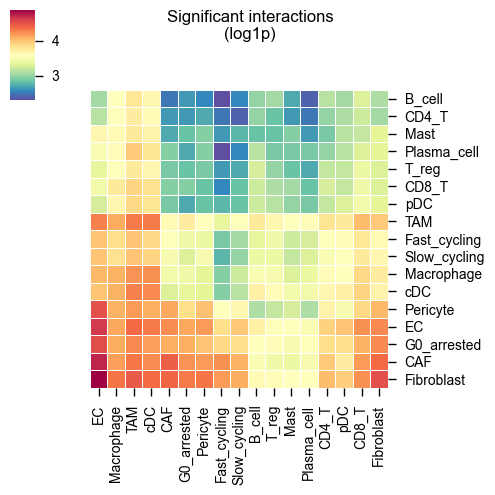

In [21]:
p = kpy.plot_cpdb_heatmap(
    pvals=pvals,
    degs_analysis=True,
    figsize=(5, 5),
    title="Significant interactions\n(log1p)",
    symmetrical=False,
    log1p_transform=True,
    cmap="Spectral_r"
)
p.savefig(figure_dir + "/cellphonedb_significant_interactions.pdf")